# Graph RAG - Knowledge Graph Enhanced Retrieval

This notebook implements Graph RAG with **local LLM (Ollama) + CUDA acceleration** for processing large email datasets (3000+).

## Features
- **Local LLM**: Uses Ollama with CUDA for fast concept extraction
- **GPU Embeddings**: HuggingFace all-MiniLM-L6-v2 with CUDA
- **Batched Processing**: Extract concepts from multiple chunks per call
- **Sparse Similarity**: Only store edges above threshold
- **Checkpointing**: Resume interrupted builds
- **No Limits**: Process all emails, not just 50

In [1]:
# Install required packages with CUDA support
# First uninstall CPU-only torch, then install PyTorch with CUDA
# Adjust cu124 to your CUDA version: cu118, cu121, cu124 (check with nvidia-smi)
!pip uninstall torch -y
!pip install torch --index-url https://download.pytorch.org/whl/cu124
!pip install faiss-cpu langchain langchain-ollama matplotlib networkx nltk numpy python-dotenv scikit-learn spacy tqdm pydantic langchain-huggingface sentence-transformers

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp313-cp313-win_amd64.whl.metadata (28 kB)
Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp313-cp313-win_amd64.whl (2532.3 MB)



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Download spaCy model
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------ --------------------------- 3.9/12.8 MB 24.8 MB/s eta 0:00:01
     ------------------------------- ------- 10.2/12.8 MB 27.4 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 26.7 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import networkx as nx
import torch
import pickle
import hashlib
from pathlib import Path

from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_ollama import ChatOllama
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import sys
import json
from dotenv import load_dotenv
from typing import List, Tuple, Dict, Optional
from pydantic import BaseModel, Field
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
import spacy
import heapq

from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import numpy as np

from spacy.cli import download
from spacy.lang.en import English

# Load environment variables
load_dotenv('backend/.env')

# Check CUDA availability with detailed diagnostics
print("=" * 50)
print("CUDA / GPU Diagnostics")
print("=" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA built: {torch.backends.cudnn.enabled if torch.cuda.is_available() else 'N/A'}")

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    # Verify CUDA is actually working
    try:
        test_tensor = torch.zeros(1).cuda()
        print("CUDA test: PASSED")
    except Exception as e:
        print(f"CUDA test FAILED: {e}")
        DEVICE = "cpu"
else:
    DEVICE = "cpu"
    print("\nWARNING: CUDA not available!")
    print("To enable GPU acceleration:")
    print("1. Ensure you have an NVIDIA GPU")
    print("2. Install CUDA toolkit from https://developer.nvidia.com/cuda-downloads")
    print("3. Reinstall PyTorch with CUDA:")
    print("   pip install torch --index-url https://download.pytorch.org/whl/cu124")
    print("   (Replace cu124 with your CUDA version: cu118, cu121, etc.)")

print(f"\nUsing device: {DEVICE}")
print("=" * 50)

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

print("\nEnvironment loaded successfully!")

CUDA / GPU Diagnostics
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA built: True
CUDA version: 12.4
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070 Laptop GPU
GPU memory: 8.0 GB
CUDA test: PASSED

Using device: cuda

Environment loaded successfully!


## Configuration

Adjust these settings based on your hardware and requirements.

In [4]:
# =============================================================================
# CONFIGURATION - Adjust these for your setup
# =============================================================================

# Ollama Configuration (local LLM)
OLLAMA_BASE_URL = os.getenv('OLLAMA_BASE_URL', 'http://localhost:11434')
OLLAMA_MODEL = os.getenv('OLLAMA_MODEL', 'llama3.2:3b-instruct-q4_0')  # Fast model for concept extraction

# Processing Configuration
BATCH_SIZE = 5  # Number of chunks to process per LLM call
MAX_WORKERS = 4  # Parallel workers for concept extraction
CHUNK_SIZE = 1000  # Characters per chunk
CHUNK_OVERLAP = 200  # Overlap between chunks

# Graph Configuration
SIMILARITY_THRESHOLD = 0.75  # Only create edges above this similarity
CHECKPOINT_DIR = Path("./graph_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Email Loading (NO LIMITS - process all emails)
MAX_EMAILS = None  # Set to None for unlimited, or a number for testing

print(f"Configuration:")
print(f"  Ollama URL: {OLLAMA_BASE_URL}")
print(f"  Ollama Model: {OLLAMA_MODEL}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Similarity Threshold: {SIMILARITY_THRESHOLD}")
print(f"  Max Emails: {'Unlimited' if MAX_EMAILS is None else MAX_EMAILS}")

Configuration:
  Ollama URL: http://localhost:11434
  Ollama Model: llama3.2:3b-instruct-q4_0
  Batch Size: 5
  Similarity Threshold: 0.75
  Max Emails: Unlimited


## Document Processor Class

Handles text splitting and embedding creation with GPU acceleration.

In [5]:
class DocumentProcessor:
    def __init__(self):
        """
        Initializes the DocumentProcessor with GPU-accelerated embeddings.
        """
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=CHUNK_SIZE, 
            chunk_overlap=CHUNK_OVERLAP
        )
        
        # GPU-accelerated HuggingFace embeddings
        # Use larger batch size for GPU, smaller for CPU
        batch_size = 64 if DEVICE == "cuda" else 16
        
        self.embeddings = HuggingFaceEmbeddings(
            model_name="all-MiniLM-L6-v2",
            model_kwargs={
                "device": DEVICE,
            },
            encode_kwargs={
                "batch_size": batch_size,
                "normalize_embeddings": True
            },
            show_progress=True
        )
        print(f"Embeddings initialized on {DEVICE} (batch_size={batch_size})")

    def process_documents(self, documents):
        """
        Processes documents: splits into chunks and creates vector store.
        """
        print(f"Splitting {len(documents)} documents...")
        splits = self.text_splitter.split_documents(documents)
        print(f"Created {len(splits)} chunks")
        
        print(f"Creating vector store on {DEVICE} (this may take a while for large datasets)...")
        vector_store = FAISS.from_documents(splits, self.embeddings)
        return splits, vector_store

    def create_embeddings_batch(self, texts, batch_size=None):
        """
        Creates embeddings in batches with progress bar.
        """
        if batch_size is None:
            batch_size = 64 if DEVICE == "cuda" else 16
            
        embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Creating embeddings ({DEVICE})"):
            batch = texts[i:i+batch_size]
            batch_embeddings = self.embeddings.embed_documents(batch)
            embeddings.extend(batch_embeddings)
        return np.array(embeddings)

## Knowledge Graph Class

Builds and manages the knowledge graph with:
- Local LLM for concept extraction
- Batched processing
- Sparse similarity matrix
- Checkpointing support

In [6]:
# Pydantic model for concept extraction
class Concepts(BaseModel):
    concepts_list: List[str] = Field(description="List of concepts")


class KnowledgeGraph:
    def __init__(self):
        """
        Initializes the KnowledgeGraph with local LLM support.
        """
        self.graph = nx.Graph()
        self.lemmatizer = WordNetLemmatizer()
        self.concept_cache = {}
        self.nlp = self._load_spacy_model()
        self.edges_threshold = SIMILARITY_THRESHOLD
        self.checkpoint_file = CHECKPOINT_DIR / "graph_checkpoint.pkl"

    def _load_spacy_model(self):
        """Loads the spaCy NLP model."""
        try:
            return spacy.load("en_core_web_sm")
        except OSError:
            print("Downloading spaCy model...")
            download("en_core_web_sm")
            return spacy.load("en_core_web_sm")

    def save_checkpoint(self, stage: str):
        """Saves current progress to checkpoint file."""
        checkpoint = {
            "stage": stage,
            "graph": self.graph,
            "concept_cache": self.concept_cache
        }
        with open(self.checkpoint_file, "wb") as f:
            pickle.dump(checkpoint, f)
        print(f"Checkpoint saved: {stage}")

    def load_checkpoint(self) -> Optional[str]:
        """Loads checkpoint if exists. Returns the stage name or None."""
        if self.checkpoint_file.exists():
            with open(self.checkpoint_file, "rb") as f:
                checkpoint = pickle.load(f)
            self.graph = checkpoint["graph"]
            self.concept_cache = checkpoint["concept_cache"]
            print(f"Resumed from checkpoint: {checkpoint['stage']}")
            return checkpoint["stage"]
        return None

    def build_graph(self, splits, llm, embedding_model):
        """
        Builds the knowledge graph with checkpointing support.
        """
        # Check for existing checkpoint
        stage = self.load_checkpoint()
        
        if stage is None or stage == "start":
            print("\n=== Stage 1/4: Adding nodes ===")
            self._add_nodes(splits)
            self.save_checkpoint("nodes_added")
        
        if stage in [None, "start", "nodes_added"]:
            print("\n=== Stage 2/4: Creating embeddings ===")
            embeddings = self._create_embeddings(splits, embedding_model)
            # Store embeddings temporarily for edge creation
            self._temp_embeddings = embeddings
            self.save_checkpoint("embeddings_created")
        else:
            # Recreate embeddings if resuming after this stage
            print("Recreating embeddings for resumed build...")
            embeddings = self._create_embeddings(splits, embedding_model)
            self._temp_embeddings = embeddings
        
        if stage in [None, "start", "nodes_added", "embeddings_created"]:
            print("\n=== Stage 3/4: Extracting concepts (batched) ===")
            self._extract_concepts_batched(splits, llm)
            self.save_checkpoint("concepts_extracted")
        
        if stage in [None, "start", "nodes_added", "embeddings_created", "concepts_extracted"]:
            print("\n=== Stage 4/4: Adding edges (sparse) ===")
            self._add_edges_sparse(self._temp_embeddings)
            self.save_checkpoint("complete")
        
        print(f"\nGraph built: {len(self.graph.nodes)} nodes, {len(self.graph.edges)} edges")

    def _add_nodes(self, splits):
        """Adds nodes with progress bar."""
        for i, split in tqdm(enumerate(splits), total=len(splits), desc="Adding nodes"):
            self.graph.add_node(i, content=split.page_content)

    def _create_embeddings(self, splits, embedding_model):
        """Creates embeddings with batch processing on GPU/CPU."""
        texts = [split.page_content for split in splits]
        
        # Use larger batch size for GPU, smaller for CPU
        batch_size = 128 if DEVICE == "cuda" else 32
        all_embeddings = []
        
        print(f"Creating embeddings on {DEVICE} (batch_size={batch_size})...")
        
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Embedding batches ({DEVICE})"):
            batch = texts[i:i+batch_size]
            batch_embeddings = embedding_model.embed_documents(batch)
            all_embeddings.extend(batch_embeddings)
            
            # Clear GPU cache periodically to prevent memory buildup
            if DEVICE == "cuda" and i % (batch_size * 10) == 0:
                torch.cuda.empty_cache()
        
        return np.array(all_embeddings)

    def _extract_concepts_and_entities(self, content: str, llm) -> List[str]:
        """
        Extracts concepts using spaCy (fast) + LLM (detailed).
        """
        # Check cache first
        content_hash = hashlib.md5(content.encode()).hexdigest()
        if content_hash in self.concept_cache:
            return self.concept_cache[content_hash]
        
        # Extract named entities using spaCy (fast, local)
        doc = self.nlp(content[:5000])  # Limit for large texts
        named_entities = [ent.text for ent in doc.ents 
                         if ent.label_ in ["PERSON", "ORG", "GPE", "DATE", "WORK_OF_ART"]]
        
        # For LLM concept extraction, use a simpler prompt
        try:
            prompt = f"""Extract 3-5 key topics/concepts from this text. Return ONLY a comma-separated list, nothing else.

Text: {content[:1000]}

Concepts:"""
            response = llm.invoke(prompt)
            concepts_text = response.content if hasattr(response, 'content') else str(response)
            general_concepts = [c.strip() for c in concepts_text.split(",") if c.strip()]
        except Exception as e:
            general_concepts = []
        
        all_concepts = list(set(named_entities + general_concepts))[:10]  # Limit concepts per node
        self.concept_cache[content_hash] = all_concepts
        return all_concepts

    def _extract_concepts_batched(self, splits, llm):
        """
        Extracts concepts with batched LLM calls for efficiency.
        """
        # Process nodes that don't have concepts yet
        nodes_to_process = [i for i in range(len(splits)) 
                           if 'concepts' not in self.graph.nodes.get(i, {})]
        
        if not nodes_to_process:
            print("All concepts already extracted (from checkpoint)")
            return
        
        print(f"Extracting concepts for {len(nodes_to_process)} nodes...")
        
        # Process in batches
        for i in tqdm(range(0, len(nodes_to_process), BATCH_SIZE), 
                      desc="Extracting concepts"):
            batch_nodes = nodes_to_process[i:i+BATCH_SIZE]
            
            for node_idx in batch_nodes:
                try:
                    content = splits[node_idx].page_content
                    concepts = self._extract_concepts_and_entities(content, llm)
                    self.graph.nodes[node_idx]['concepts'] = concepts
                except Exception as e:
                    print(f"Error for node {node_idx}: {e}")
                    self.graph.nodes[node_idx]['concepts'] = []
            
            # Save checkpoint every 100 batches
            if (i // BATCH_SIZE) % 100 == 0 and i > 0:
                self.save_checkpoint("concepts_in_progress")

    def _add_edges_sparse(self, embeddings):
        """
        Adds edges using sparse computation - only computes similarities above threshold.
        Uses chunked processing to avoid memory issues with large matrices.
        """
        num_nodes = len(self.graph.nodes)
        print(f"Computing sparse similarities for {num_nodes} nodes...")
        
        # Process in chunks to avoid memory overflow
        chunk_size = 500  # Process 500 nodes at a time
        edge_count = 0
        
        for i in tqdm(range(0, num_nodes, chunk_size), desc="Adding edges"):
            chunk_end = min(i + chunk_size, num_nodes)
            chunk_embeddings = embeddings[i:chunk_end]
            
            # Compute similarities between this chunk and all nodes after it
            for j in range(i, num_nodes, chunk_size):
                j_end = min(j + chunk_size, num_nodes)
                other_embeddings = embeddings[j:j_end]
                
                # Compute similarity matrix for this chunk pair
                if i == j:
                    # Same chunk - only upper triangle
                    sim_matrix = cosine_similarity(chunk_embeddings)
                    for local_i in range(len(chunk_embeddings)):
                        for local_j in range(local_i + 1, len(chunk_embeddings)):
                            if sim_matrix[local_i][local_j] > self.edges_threshold:
                                node1 = i + local_i
                                node2 = i + local_j
                                self._add_edge(node1, node2, sim_matrix[local_i][local_j])
                                edge_count += 1
                else:
                    # Different chunks - full comparison
                    sim_matrix = cosine_similarity(chunk_embeddings, other_embeddings)
                    for local_i in range(len(chunk_embeddings)):
                        for local_j in range(len(other_embeddings)):
                            if sim_matrix[local_i][local_j] > self.edges_threshold:
                                node1 = i + local_i
                                node2 = j + local_j
                                if node1 < node2:  # Avoid duplicates
                                    self._add_edge(node1, node2, sim_matrix[local_i][local_j])
                                    edge_count += 1
        
        print(f"Added {edge_count} edges above threshold {self.edges_threshold}")

    def _add_edge(self, node1: int, node2: int, similarity: float):
        """Adds a single edge with computed weight."""
        concepts1 = set(self.graph.nodes[node1].get('concepts', []))
        concepts2 = set(self.graph.nodes[node2].get('concepts', []))
        shared_concepts = concepts1 & concepts2
        
        # Calculate weight
        max_possible = min(len(concepts1), len(concepts2)) if concepts1 and concepts2 else 1
        normalized_shared = len(shared_concepts) / max_possible if max_possible > 0 else 0
        weight = 0.7 * similarity + 0.3 * normalized_shared
        
        self.graph.add_edge(node1, node2, 
                           weight=weight,
                           similarity=similarity,
                           shared_concepts=list(shared_concepts))

    def _lemmatize_concept(self, concept):
        """Lemmatizes a given concept."""
        return ' '.join([self.lemmatizer.lemmatize(word) for word in concept.lower().split()])

## Query Engine Class

Handles graph traversal and answer generation.

In [7]:
# Pydantic model for answer checking
class AnswerCheck(BaseModel):
    is_complete: bool = Field(description="Whether the current context provides a complete answer")
    answer: str = Field(description="The current answer based on the context")


class QueryEngine:
    def __init__(self, vector_store, knowledge_graph, llm):
        self.vector_store = vector_store
        self.knowledge_graph = knowledge_graph
        self.llm = llm
        self.max_context_length = 4000

    def _check_answer(self, query: str, context: str) -> Tuple[bool, str]:
        """Checks if context provides complete answer."""
        try:
            prompt = f"""Given this query and context, determine if the context provides a complete answer.

Query: {query}
Context: {context[:2000]}

If sufficient, provide the answer. If not, say "INCOMPLETE".
Answer:"""
            response = self.llm.invoke(prompt)
            answer = response.content if hasattr(response, 'content') else str(response)
            is_complete = "INCOMPLETE" not in answer.upper()
            return is_complete, answer
        except Exception as e:
            print(f"Answer check error: {e}")
            return False, ""

    def _expand_context(self, query: str, relevant_docs) -> Tuple[str, List[int], Dict[int, str], str]:
        """
        Expands context by traversing the knowledge graph.
        """
        expanded_context = ""
        traversal_path = []
        visited_concepts = set()
        filtered_content = {}
        final_answer = ""
        
        priority_queue = []
        distances = {}
        
        print("\nTraversing the knowledge graph:")
        
        # Initialize with relevant docs
        for doc in relevant_docs:
            closest_nodes = self.vector_store.similarity_search_with_score(doc.page_content, k=1)
            if closest_nodes:
                closest_node_content, similarity_score = closest_nodes[0]
                
                # Find matching node
                closest_node = None
                for n in self.knowledge_graph.graph.nodes:
                    if self.knowledge_graph.graph.nodes[n]['content'] == closest_node_content.page_content:
                        closest_node = n
                        break
                
                if closest_node is not None:
                    priority = 1 / max(similarity_score, 0.001)
                    heapq.heappush(priority_queue, (priority, closest_node))
                    distances[closest_node] = priority
        
        step = 0
        max_steps = 10  # Limit traversal depth
        
        while priority_queue and step < max_steps:
            current_priority, current_node = heapq.heappop(priority_queue)
            
            if current_priority > distances.get(current_node, float('inf')):
                continue
            
            if current_node not in traversal_path:
                step += 1
                traversal_path.append(current_node)
                node_content = self.knowledge_graph.graph.nodes[current_node]['content']
                node_concepts = self.knowledge_graph.graph.nodes[current_node].get('concepts', [])
                
                filtered_content[current_node] = node_content
                expanded_context += "\n" + node_content if expanded_context else node_content
                
                print(f"Step {step} - Node {current_node}: {', '.join(node_concepts[:3])}")
                
                # Check for complete answer
                if len(expanded_context) > 1000:  # Only check after sufficient context
                    is_complete, answer = self._check_answer(query, expanded_context)
                    if is_complete:
                        final_answer = answer
                        break
                
                # Expand to neighbors
                for neighbor in self.knowledge_graph.graph.neighbors(current_node):
                    edge_data = self.knowledge_graph.graph[current_node][neighbor]
                    edge_weight = edge_data['weight']
                    distance = current_priority + (1 / max(edge_weight, 0.001))
                    
                    if distance < distances.get(neighbor, float('inf')):
                        distances[neighbor] = distance
                        heapq.heappush(priority_queue, (distance, neighbor))

        # Generate answer if not found during traversal
        if not final_answer:
            print("\nGenerating final answer...")
            prompt = f"""Based on the following context, answer the query.

Context: {expanded_context[:3000]}

Query: {query}

Answer:"""
            response = self.llm.invoke(prompt)
            final_answer = response.content if hasattr(response, 'content') else str(response)

        return expanded_context, traversal_path, filtered_content, final_answer

    def query(self, query: str) -> Tuple[str, List[int], Dict[int, str]]:
        """Processes a query and returns answer, path, and content."""
        print(f"\nProcessing query: {query}")
        relevant_docs = self._retrieve_relevant_documents(query)
        expanded_context, traversal_path, filtered_content, final_answer = self._expand_context(query, relevant_docs)
        
        print(f"\nFinal Answer: {final_answer}")
        return final_answer, traversal_path, filtered_content

    def _retrieve_relevant_documents(self, query: str):
        """Retrieves relevant documents."""
        print("Retrieving relevant documents...")
        retriever = self.vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 5})
        return retriever.invoke(query)

## Visualizer Class

In [8]:
class Visualizer:
    @staticmethod
    def visualize_traversal(graph, traversal_path):
        """Visualizes the traversal path on the knowledge graph."""
        if not traversal_path:
            print("No traversal path to visualize.")
            return
            
        # Create subgraph with traversal nodes and their neighbors
        relevant_nodes = set(traversal_path)
        for node in traversal_path:
            relevant_nodes.update(graph.neighbors(node))
        
        subgraph = graph.subgraph(relevant_nodes)
        
        fig, ax = plt.subplots(figsize=(14, 10))
        pos = nx.spring_layout(subgraph, k=2, iterations=50)
        
        # Draw all edges
        nx.draw_networkx_edges(subgraph, pos, alpha=0.3, ax=ax)
        
        # Draw all nodes
        node_colors = ['lightgreen' if n == traversal_path[0] 
                       else 'lightcoral' if n == traversal_path[-1]
                       else 'lightblue' if n in traversal_path
                       else 'lightgray' 
                       for n in subgraph.nodes()]
        
        nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, 
                               node_size=1000, ax=ax)
        
        # Draw traversal path arrows
        for i in range(len(traversal_path) - 1):
            start, end = traversal_path[i], traversal_path[i + 1]
            if start in pos and end in pos:
                arrow = patches.FancyArrowPatch(pos[start], pos[end],
                                                connectionstyle="arc3,rad=0.2",
                                                color='red', arrowstyle="->",
                                                mutation_scale=15, linewidth=2,
                                                zorder=4)
                ax.add_patch(arrow)
        
        # Labels
        labels = {n: str(traversal_path.index(n) + 1) if n in traversal_path else '' 
                  for n in subgraph.nodes()}
        nx.draw_networkx_labels(subgraph, pos, labels, font_size=10, font_weight="bold", ax=ax)
        
        ax.set_title(f"Graph Traversal ({len(traversal_path)} steps)")
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## Graph RAG Main Class

In [9]:
class GraphRAG:
    def __init__(self):
        """
        Initializes GraphRAG with local Ollama LLM and GPU embeddings.
        """
        print("Initializing GraphRAG with local LLM...")
        
        # Local LLM via Ollama (CUDA accelerated if available)
        self.llm = ChatOllama(
            model=OLLAMA_MODEL,
            base_url=OLLAMA_BASE_URL,
            temperature=0,
            num_ctx=4096,  # Context window
        )
        print(f"LLM: Ollama ({OLLAMA_MODEL})")
        
        # GPU-accelerated embeddings with optimized settings
        batch_size = 64 if DEVICE == "cuda" else 16
        self.embedding_model = HuggingFaceEmbeddings(
            model_name="all-MiniLM-L6-v2",
            model_kwargs={
                "device": DEVICE,
            },
            encode_kwargs={
                "batch_size": batch_size,
                "normalize_embeddings": True
            },
            show_progress=True
        )
        print(f"Embeddings: HuggingFace all-MiniLM-L6-v2 on {DEVICE} (batch_size={batch_size})")
        
        self.document_processor = DocumentProcessor()
        self.knowledge_graph = KnowledgeGraph()
        self.query_engine = None
        self.visualizer = Visualizer()

    def process_documents(self, documents):
        """Processes documents and builds knowledge graph."""
        print(f"\n{'='*60}")
        print(f"Processing {len(documents)} documents on {DEVICE}")
        print(f"{'='*60}")
        
        splits, vector_store = self.document_processor.process_documents(documents)
        
        print(f"\nBuilding knowledge graph...")
        self.knowledge_graph.build_graph(splits, self.llm, self.embedding_model)
        
        self.query_engine = QueryEngine(vector_store, self.knowledge_graph, self.llm)
        print("\n✓ Ready for queries!")

    def query(self, query: str):
        """Queries the knowledge graph."""
        if not self.query_engine:
            print("Error: No documents processed. Call process_documents first.")
            return None
            
        response, traversal_path, filtered_content = self.query_engine.query(query)
        
        if traversal_path:
            self.visualizer.visualize_traversal(self.knowledge_graph.graph, traversal_path)
        
        return response
    
    def clear_checkpoint(self):
        """Clears checkpoint to start fresh."""
        checkpoint_file = CHECKPOINT_DIR / "graph_checkpoint.pkl"
        if checkpoint_file.exists():
            checkpoint_file.unlink()
            print("Checkpoint cleared.")
        else:
            print("No checkpoint to clear.")

## Load Email Data

Load ALL extracted emails - no artificial limits!

In [10]:
def load_emails_as_documents(extracted_dir="backend/data/extracted", max_emails=None):
    """
    Loads ALL extracted emails from JSON files.
    
    Args:
    - extracted_dir: Directory containing extracted email JSON files
    - max_emails: Maximum emails to load (None = unlimited)
    
    Returns:
    - List of LangChain Document objects
    """
    documents = []
    total_loaded = 0
    
    if not os.path.exists(extracted_dir):
        print(f"Directory not found: {extracted_dir}")
        return documents
    
    json_files = [f for f in os.listdir(extracted_dir) if f.endswith('.json')]
    print(f"Found {len(json_files)} JSON files")
    
    for json_file in tqdm(json_files, desc="Loading emails"):
        if max_emails and total_loaded >= max_emails:
            break
            
        filepath = os.path.join(extracted_dir, json_file)
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            # Handle both single dict and list
            if isinstance(data, dict):
                data = [data]
            
            for email in data:
                if max_emails and total_loaded >= max_emails:
                    break
                
                # Create rich text content
                content = f"""Date: {email.get('date', 'Unknown')}
From: {email.get('from', 'Unknown')}
To: {email.get('to', 'Unknown')}
Subject: {email.get('subject', 'No Subject')}

{email.get('body', '')}"""
                
                doc = Document(
                    page_content=content,
                    metadata={
                        "email_id": email.get('email_id', ''),
                        "date": email.get('date', ''),
                        "sender": email.get('from', ''),
                        "subject": email.get('subject', '')
                    }
                )
                documents.append(doc)
                total_loaded += 1
                
        except Exception as e:
            print(f"Error loading {json_file}: {e}")
    
    print(f"\nLoaded {len(documents)} emails as documents")
    return documents


# Load emails (no limit by default)
documents = load_emails_as_documents(max_emails=MAX_EMAILS)

# Preview
if documents:
    print("\n--- First Document Preview ---")
    print(documents[0].page_content[:500])

Found 2 JSON files


Loading emails: 100%|██████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  2.97it/s]


Loaded 3178 emails as documents

--- First Document Preview ---
Date: New U.S. Entry Restrictions Effective January 1, 2026.msg
From: Unknown Sender
To: 
Subject: Software Tester Position Referral.msg

Top of Outlook data file
Deleted Items
Istiqlal_Regular Meeting.msg

Re: Student Insurance.msg

New items were added to 'HCC 6300- Game Design'.msg

Verify your student email address.msg

Istiqlal Meeting.msg

Get an Envelop from Post Office.msg

Buy Direct from Cengage and Pay Less for Course Materials.msg

Weekly update in AI-Receptive Software Development.m


## Verify Ollama is Running

Make sure Ollama is running locally before proceeding.

In [11]:
import requests

def check_ollama():
    """Verify Ollama is running and the model is available."""
    try:
        response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
        if response.status_code == 200:
            models = response.json().get('models', [])
            model_names = [m['name'] for m in models]
            print(f"✓ Ollama is running")
            print(f"  Available models: {model_names}")
            
            if not any(OLLAMA_MODEL in name for name in model_names):
                print(f"\n⚠ Model '{OLLAMA_MODEL}' not found. Pull it with:")
                print(f"  ollama pull {OLLAMA_MODEL}")
                return False
            return True
    except requests.exceptions.ConnectionError:
        print("✗ Ollama is not running!")
        print("  Start it with: ollama serve")
        return False
    except Exception as e:
        print(f"Error checking Ollama: {e}")
        return False

ollama_ready = check_ollama()

✓ Ollama is running
  Available models: ['llama3.2:3b-instruct-q4_0', 'llama3.2:3b', 'llama3.2:latest']


## Create Graph RAG Instance and Process Documents

In [12]:
# Optional: Clear checkpoint to start fresh
# Uncomment the next line to clear existing checkpoint
# KnowledgeGraph().save_checkpoint("start")  # This will reset the checkpoint

# Create Graph RAG instance
graph_rag = GraphRAG()

# Process documents and build the knowledge graph
if documents:
    graph_rag.process_documents(documents)
else:
    print("No documents loaded. Check your extracted email files.")

Initializing GraphRAG with local LLM...
LLM: Ollama (llama3.2:3b-instruct-q4_0)
Embeddings: HuggingFace all-MiniLM-L6-v2 on cuda (batch_size=64)
Embeddings initialized on cuda (batch_size=64)

Processing 3178 documents on cuda
Splitting 3178 documents...
Created 42459 chunks
Creating vector store on cuda (this may take a while for large datasets)...


Batches:   0%|          | 0/664 [00:00<?, ?it/s]


Building knowledge graph...
Resumed from checkpoint: concepts_in_progress
Recreating embeddings for resumed build...
Creating embeddings on cuda (batch_size=128)...


Embedding batches (cuda):   0%|                                                                  | 0/332 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding batches (cuda): 100%|███████████████████████████████████████████████████████▊| 331/332 [01:15<00:00,  4.14it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding batches (cuda): 100%|████████████████████████████████████████████████████████| 332/332 [01:16<00:00,  4.36it/s]



Graph built: 42459 nodes, 0 edges

✓ Ready for queries!


## Query the Graph RAG System


Processing query: What are the main topics discussed in my emails?
Retrieving relevant documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Traversing the knowledge graph:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Step 1 - Node 7730: 
Step 2 - Node 14625: 
Step 3 - Node 20689: 
Step 4 - Node 27193: 
Step 5 - Node 34717: 

Generating final answer...

Final Answer: The main topics discussed in these emails are:

1. Registration updates and changes (specifically, a new email address for registration questions and issues)
2. A reminder about Timecard Approvals due today
3. A request to open a directed studies course (6 credits) on the university's system
4. Tips and resources related to writing trends, analysis of tweets, and using Outlook for Android
5. Updates on fun events, opportunities, and English language programs at Clemson University
6. New items added to a list or database related to BIM Blockchain Carbon Emissions


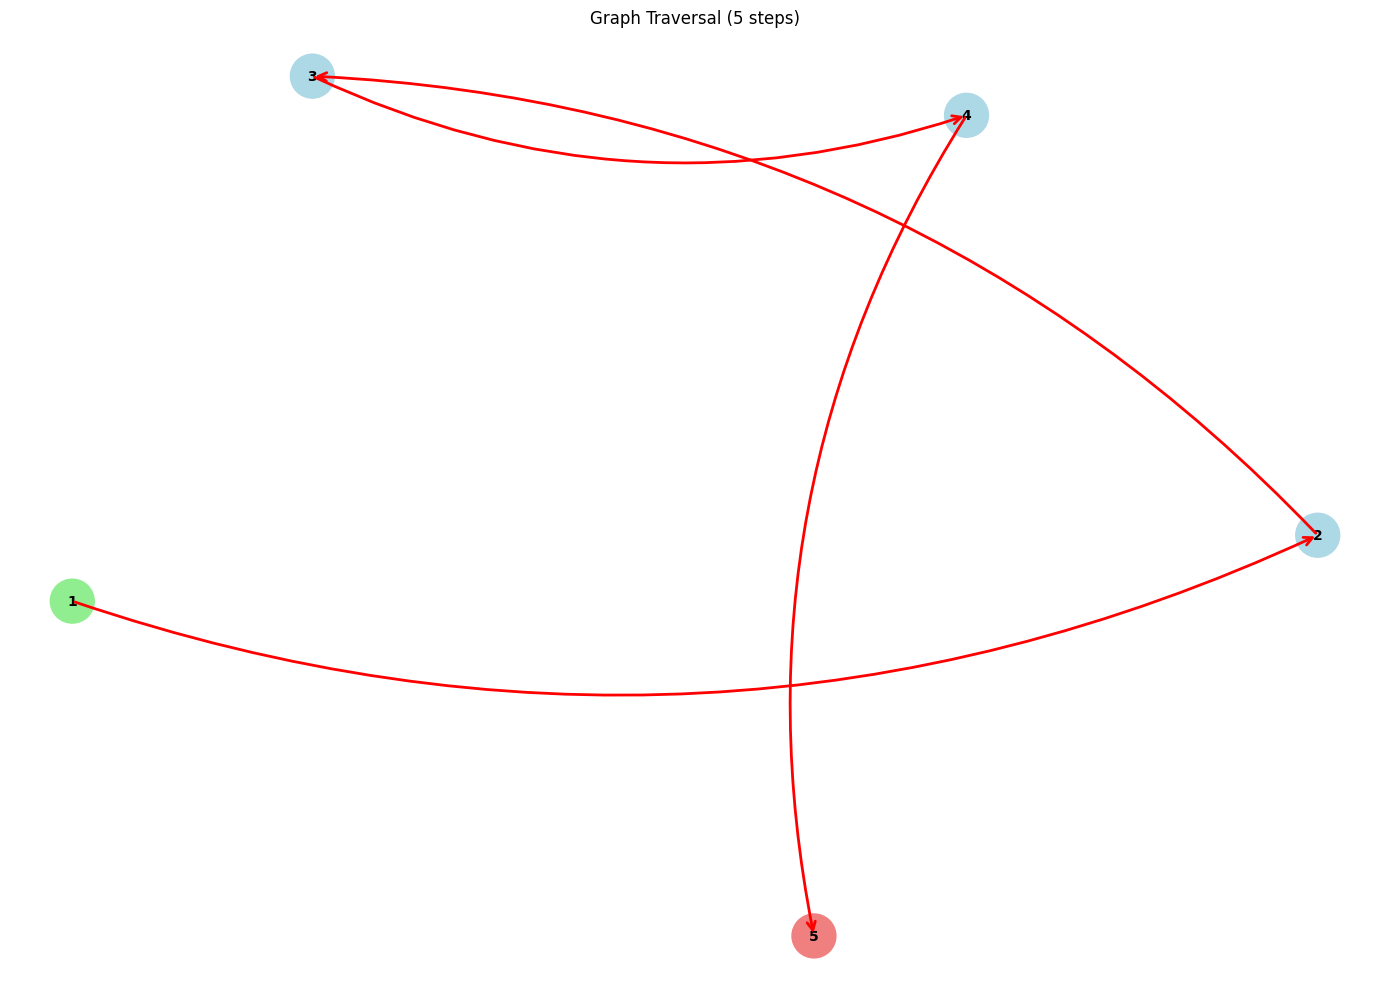

In [13]:
# Example queries
query = "What are the main topics discussed in my emails?"
response = graph_rag.query(query)


Processing query: Who are the most frequent email contacts?
Retrieving relevant documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Traversing the knowledge graph:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Step 1 - Node 14175: 
Step 2 - Node 15571: 
Step 3 - Node 22383: 
Step 4 - Node 23023: 
Step 5 - Node 27365: 

Generating final answer...

Final Answer: The query is "Who are the most frequent email contacts?"


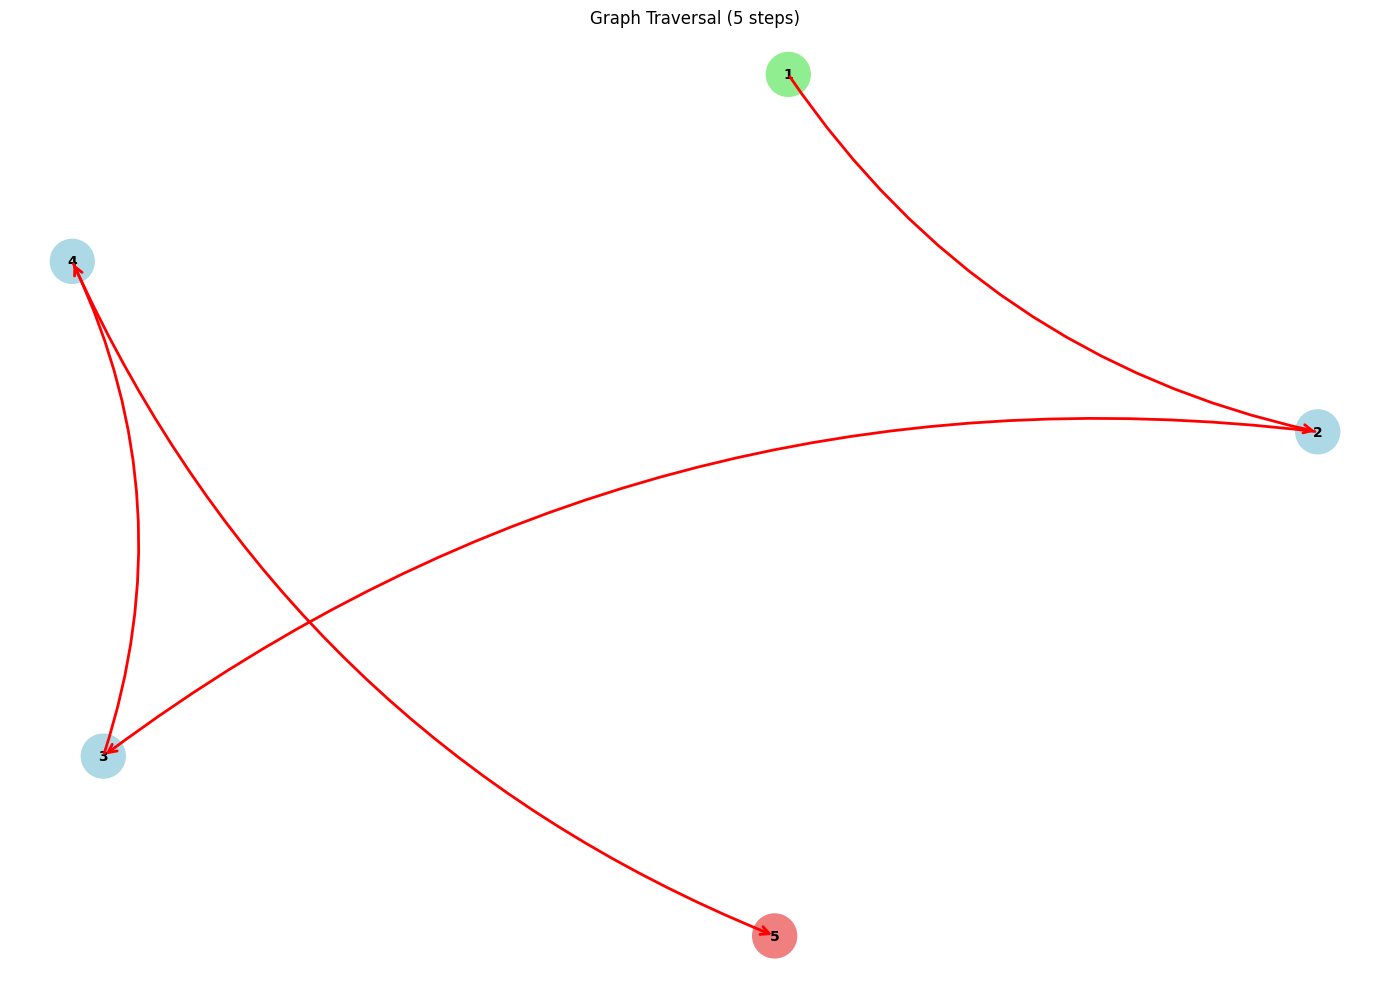

In [14]:
# Relationship query
query2 = "Who are the most frequent email contacts?"
response2 = graph_rag.query(query2)


Processing query: How has my communication pattern changed over time?
Retrieving relevant documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Traversing the knowledge graph:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Step 1 - Node 3929: 
Step 2 - Node 14012: 
Step 3 - Node 22583: 
Step 4 - Node 27365: 
Step 5 - Node 27564: 

Generating final answer...

Final Answer: Based on the provided context, I can infer that effective communication is crucial to an organization's success. It aligns employees with company goals, facilitates collaboration, enables informed decision-making, keeps employees engaged and motivated, ensures excellent customer service, manages change smoothly, resolves conflicts, and protects the company's reputation.

As for your query about how your communication pattern has changed over time, I can provide a general answer:

Communication patterns can change over time due to various factors such as personal growth, new experiences, changes in relationships, or shifts in priorities. These changes can lead to adjustments in communication styles, tone, and content, which can impact the way you interact with others.

Some possible ways your communication pattern may have changed includ

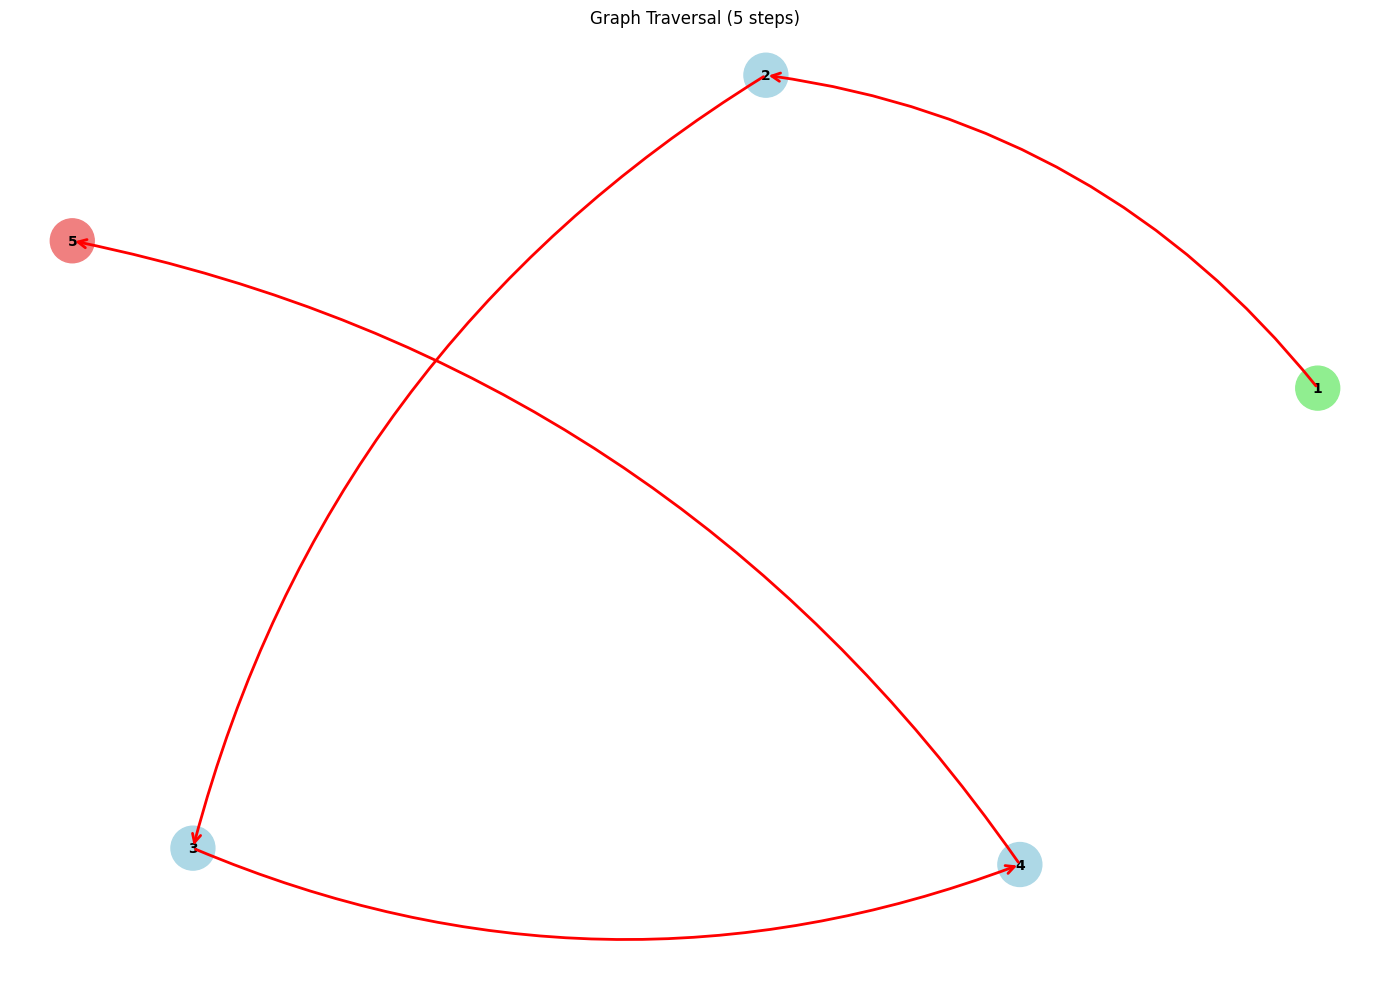

In [15]:
# Behavioral query (this is what Graph RAG excels at)
query3 = "How has my communication pattern changed over time?"
response3 = graph_rag.query(query3)


Processing query: Find emails from Dina
Retrieving relevant documents...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Traversing the knowledge graph:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Step 1 - Node 6536: 
Step 2 - Node 14175: 
Step 3 - Node 20293: 
Step 4 - Node 20295: 
Step 5 - Node 24823: 

Generating final answer...

Final Answer: There is no mention of an email from "Dina" in the provided context. The context only shows a series of links and buttons related to updating a profile, but there is no indication of any emails from someone named "Dina".


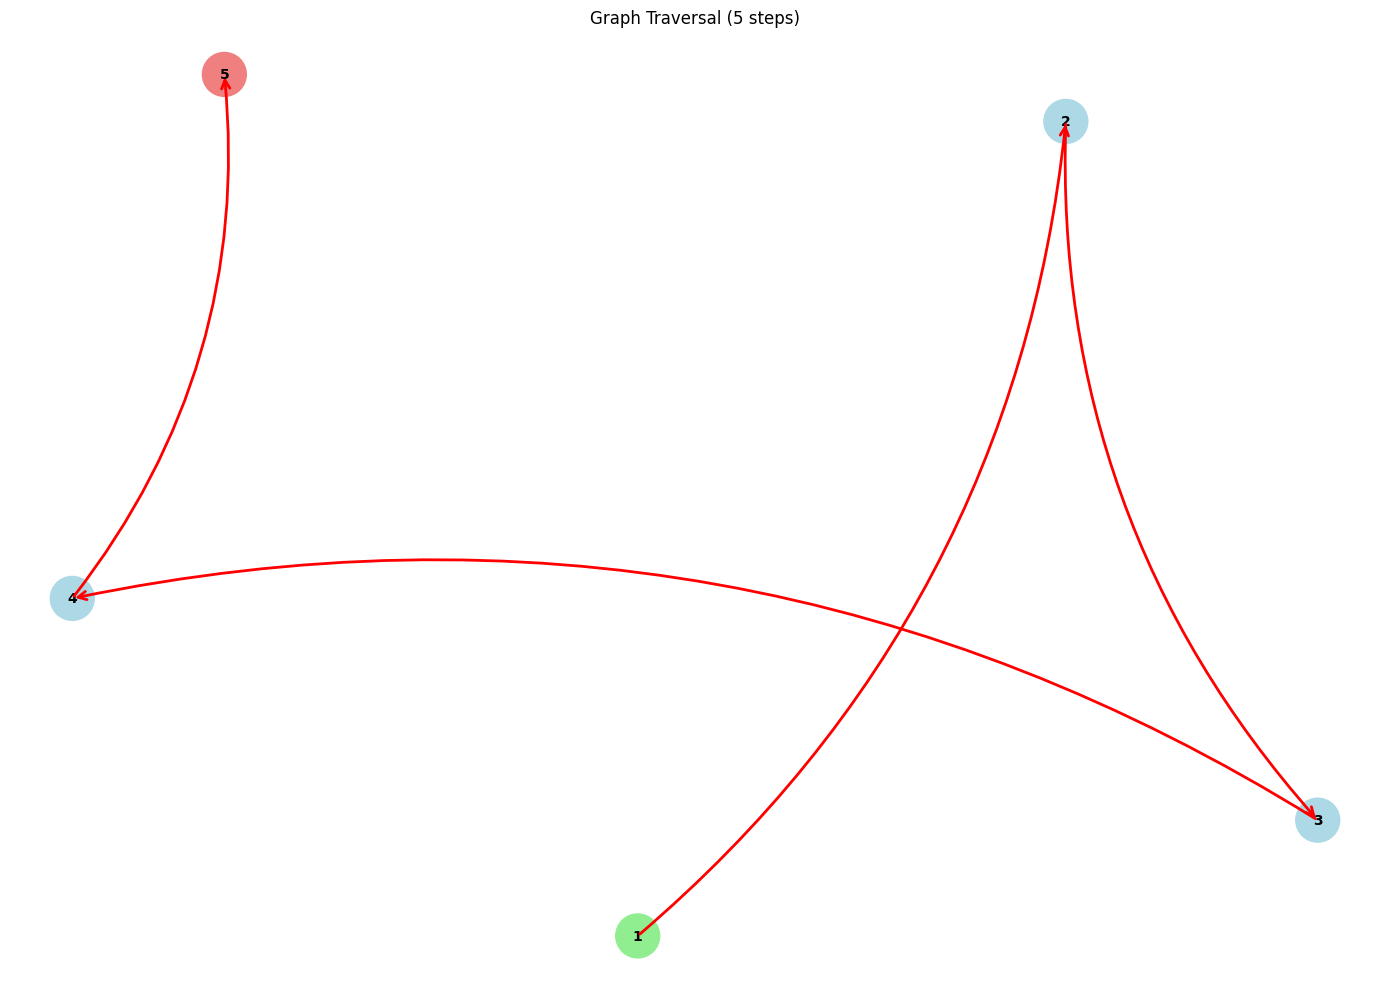

In [16]:
# Custom query
custom_query = "Find emails from Dina"
response4 = graph_rag.query(custom_query)

## Graph Statistics

In [17]:
# Print graph statistics
g = graph_rag.knowledge_graph.graph
print(f"Graph Statistics:")
print(f"  Nodes: {len(g.nodes)}")
print(f"  Edges: {len(g.edges)}")
print(f"  Density: {nx.density(g):.4f}")
if len(g.nodes) > 0:
    print(f"  Avg Degree: {sum(dict(g.degree()).values()) / len(g.nodes):.2f}")
    
# Sample concepts from a few nodes
print(f"\nSample concepts from first 5 nodes:")
for i in range(min(5, len(g.nodes))):
    concepts = g.nodes[i].get('concepts', [])
    print(f"  Node {i}: {concepts[:5]}")

Graph Statistics:
  Nodes: 42459
  Edges: 0
  Density: 0.0000
  Avg Degree: 0.00

Sample concepts from first 5 nodes:
  Node 0: ['today', 'January 1', 'Kronos Outage', 'Punch', 'Student Insurance']
  Node 1: ['Sublease Form', 'today', 'Find Your Way', 'Internships', 'Graduate Student Listening Session']
  Node 2: ['today', 'Sublease Form', 'Activity.msg', 'Internships', 'Chrome']
  Node 3: ['DEI', 'Training.msg', 'MAC Advising.msg', 'Istiqlal.msg', 'Meeting.msg']
  Node 4: ['DEI', 'AI', 'YIS', 'Vet', 'Graduate Student Listening Session']


In [18]:
ollama run llama3.2:3b-instruct-q4_0

SyntaxError: invalid decimal literal (3320692623.py, line 1)